In [14]:
import tensorflow_datasets as tfds
from tqdm import tqdm
import matplotlib.pyplot as plt
import mediapy
from PIL import Image
import numpy as np


In [15]:
# 指定本地缓存目录
ds = tfds.load(
    "droid",                # 数据集名称
    split="train",          # 数据集划分
    data_dir="/app/aaa/data/rlds_data/put_the_blue_cube_in_the_red_cup2/tensorflow_datasets/droid"  # 本地缓存路径
)

In [16]:
eps = []
for ep in tqdm(ds):
    file_path = ep["episode_metadata"]["file_path"].numpy().decode("utf-8")
    recording_folderpath = ep["episode_metadata"]["recording_folderpath"].numpy().decode("utf-8")

    break



  0%|          | 0/184 [00:00<?, ?it/s]


In [17]:
ep


{'episode_metadata': {'file_path': <tf.Tensor: shape=(), dtype=string, numpy=b'/app/data/success/2026-03-04/Wed_Mar__4_13:12:19_2026/trajectory.h5'>,
  'recording_folderpath': <tf.Tensor: shape=(), dtype=string, numpy=b'/app/data/success/2026-03-04/Wed_Mar__4_13:12:19_2026/recordings/MP4'>},
 'steps': <_VariantDataset element_spec={'action': TensorSpec(shape=(7,), dtype=tf.float64, name=None), 'action_dict': {'cartesian_position': TensorSpec(shape=(6,), dtype=tf.float64, name=None), 'cartesian_velocity': TensorSpec(shape=(6,), dtype=tf.float64, name=None), 'gripper_position': TensorSpec(shape=(1,), dtype=tf.float64, name=None), 'gripper_velocity': TensorSpec(shape=(1,), dtype=tf.float64, name=None), 'joint_position': TensorSpec(shape=(7,), dtype=tf.float64, name=None), 'joint_velocity': TensorSpec(shape=(7,), dtype=tf.float64, name=None)}, 'discount': TensorSpec(shape=(), dtype=tf.float32, name=None), 'is_first': TensorSpec(shape=(), dtype=tf.bool, name=None), 'is_last': TensorSpec(sha

In [18]:
example = ep

print("Keys:", example.keys())
print("Episode metadata:")
for k, v in example['episode_metadata'].items():
    print(f"  {k}: {v.numpy().decode('utf-8')}")
print("Steps")
for k, v in example['steps'].element_spec.items():
    print(f"  {k} : {v}")

Keys: dict_keys(['episode_metadata', 'steps'])
Episode metadata:
  file_path: /app/data/success/2026-03-04/Wed_Mar__4_13:12:19_2026/trajectory.h5
  recording_folderpath: /app/data/success/2026-03-04/Wed_Mar__4_13:12:19_2026/recordings/MP4
Steps
  action : TensorSpec(shape=(7,), dtype=tf.float64, name=None)
  action_dict : {'cartesian_position': TensorSpec(shape=(6,), dtype=tf.float64, name=None), 'cartesian_velocity': TensorSpec(shape=(6,), dtype=tf.float64, name=None), 'gripper_position': TensorSpec(shape=(1,), dtype=tf.float64, name=None), 'gripper_velocity': TensorSpec(shape=(1,), dtype=tf.float64, name=None), 'joint_position': TensorSpec(shape=(7,), dtype=tf.float64, name=None), 'joint_velocity': TensorSpec(shape=(7,), dtype=tf.float64, name=None)}
  discount : TensorSpec(shape=(), dtype=tf.float32, name=None)
  is_first : TensorSpec(shape=(), dtype=tf.bool, name=None)
  is_last : TensorSpec(shape=(), dtype=tf.bool, name=None)
  is_terminal : TensorSpec(shape=(), dtype=tf.bool, nam

In [19]:
steps = list(tfds.as_numpy(ep["steps"]))
for i in range(len(steps)):

    if i == 0:
        init_joint_position = steps[i]["observation"]["joint_position"]
        init_gripper_position = steps[i]["observation"]["gripper_position"]
        print(f"init_joint_position:{init_joint_position}")
        print(f"init_gripper_position:{init_gripper_position}")
        # action = np.concatenate([init_joint_position, [init_gripper_position]])
        # print(f"init_action:{action}")

    # print(f"Step {i}: {steps[i]['action_dict']['joint_velocity']}")

init_joint_position:[ 0.01596418 -0.35476857  0.28164339 -2.12891197 -0.14628749  1.91694593
  0.39566228]
init_gripper_position:[0.]


In [20]:
len(steps)

270

In [21]:
steps = list(tfds.as_numpy(ep["steps"]))
for i in range(len(steps)):
    print(steps[i]['observation']['exterior_image_1_left'].shape)
    print(steps[i]['observation']['exterior_image_1_left'].max())
    print(steps[i]['observation']['exterior_image_1_left'].min())
    print(steps[i]['observation']['exterior_image_1_left'].mean())
    print(steps[i]['observation']['exterior_image_1_left'].var())


    print(steps[i]['observation']['wrist_image_left'].shape)
    print(steps[i]['observation']['wrist_image_left'].max())
    print(steps[i]['observation']['wrist_image_left'].min())
    print(steps[i]['observation']['wrist_image_left'].mean())
    print(steps[i]['observation']['wrist_image_left'].var())     

    print(steps[i]['action_dict']['joint_velocity'].shape)
    print(steps[i]['action_dict']['joint_velocity'].max())
    print(steps[i]['action_dict']['joint_velocity'].min())   

    print(steps[i]['observation']['joint_position'].shape)
    print(steps[i]['observation']['joint_position'].max())
    print(steps[i]['observation']['joint_position'].min())          
    break



(180, 320, 3)
255
0
68.7886863425926
4135.366694917823
(180, 320, 3)
255
0
91.9610474537037
2668.211393578767
(7,)
0.12310317158699036
-0.10195985436439514
(7,)
1.9169459342956543
-2.1289119720458984


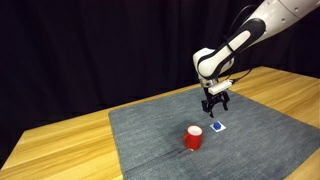

In [22]:
Image.fromarray(steps[50]['observation']['exterior_image_1_left'])

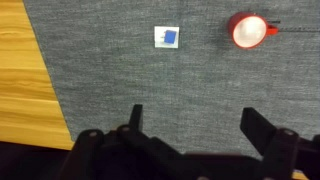

In [23]:
Image.fromarray(steps[i]['observation']['wrist_image_left'])

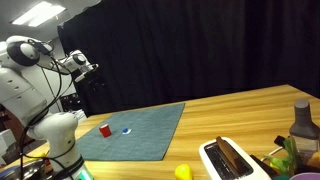

In [24]:
Image.fromarray(steps[i]['observation']['exterior_image_2_left'])

In [10]:
steps[i]['observation']['joint_position']
#[ 0.0180, -0.6926, -0.1878, -2.4668, -0.0184,  1.9020, -0.3091,  0.0000]

array([ 0.01800841, -0.6926409 , -0.18777452, -2.46676326, -0.01837285,
        1.90200365, -0.30914086])

In [11]:
steps[50]['observation']['joint_position']
# [ 0.0286,  0.0937,  0.0178, -1.9255, -0.1204,  1.9535, -0.1180,  0.0000]

array([ 0.02855293,  0.09371606,  0.01783506, -1.92553377, -0.12043503,
        1.95351672, -0.11800704])

In [12]:
steps[200]['observation']['joint_position']
# [ 0.0959, -0.0555,  0.1128, -2.1780,  0.1832,  1.9665, -0.2860,  0.0000]

array([ 0.09592854, -0.05549438,  0.11284655, -2.17801499,  0.18319309,
        1.96647334, -0.2859638 ])

In [16]:
print(f"steps[0]['action']:")
print(f"{steps[0]['action']}")

print(f"steps[0]['action_dict']['cartesian_position']:")
print(f"{steps[0]['action_dict']['cartesian_position']}")


print(f"steps[0]['action_dict']['cartesian_velocity']:")
print(f"{steps[0]['action_dict']['cartesian_velocity']}")

print(f"steps[0]['action_dict']['joint_position']:")
print(f"{steps[0]['action_dict']['joint_position']}")

print(f"steps[0]['action_dict']['joint_velocity']:")
print(f"{steps[0]['action_dict']['joint_velocity']}")




steps[0]['action']:
[ 0.45622584  0.00897394  0.4842746   3.07503724  0.18696691 -0.0489166
  0.        ]
steps[0]['action_dict']['cartesian_position']:
[ 0.45622584  0.00897394  0.4842746   3.07503724  0.18696691 -0.0489166 ]
steps[0]['action_dict']['cartesian_velocity']:
[0. 0. 0. 0. 0. 0.]
steps[0]['action_dict']['joint_position']:
[-6.21540239e-04 -2.51441807e-01  2.83429194e-02 -2.16950703e+00
 -4.58437055e-02  1.72594106e+00  8.01781565e-02]
steps[0]['action_dict']['joint_velocity']:
[ 0.01745088  0.00252903 -0.0148124   0.00874722 -0.00261115 -0.01017993
  0.00325975]


In [34]:
image_name="exterior_image_1_left"
images = []
cartesian_poses = []
for step in ep["steps"]:
    image = step["observation"][image_name].numpy()
    images.append(image)
    cartesian_pose = step["observation"]["cartesian_position"].numpy()
    cartesian_poses.append(cartesian_pose)

In [35]:
path_to_droid_repo = "/app"
# Visualize!
vis_images = []
temp_img_path = f"{path_to_droid_repo}/TEMP.png"

for i, image in enumerate(tqdm(images)):
    # if i % 10 != 0:
    #     continue
    
    # fig, axs = plt.subplots(1)
    # # x, y = pixel_positions[0, i] / 1280 * 320, pixel_positions[1, i] / 720 * 180 # Scale to match image dimensions

    # # clip coords
    # # x = np.clip(x, 0, 320)
    # # y = np.clip(y, 0, 180)

    # axs.imshow(image)
    # # axs.scatter(x, y, c='red', s=20)
    # axs.set_xlim(0, 320)
    # axs.set_ylim(180, 0)  # Invert y-axis to match image

    # # turn off axes
    # axs.axis('off')

    # # save the figure, then reopen it as PIL image
    # plt.savefig(temp_img_path, bbox_inches='tight', pad_inches=0)
    # plt.close(fig)

    # vis_image = Image.open(temp_img_path).convert("RGB")
    vis_images.append(np.array(image))

100%|██████████| 493/493 [00:00<00:00, 9307.92it/s]


In [36]:
# Visualize the video
mediapy.show_video(
    vis_images,
    fps=4
)

This browser does not support the video tag.
